
# Lab 6: FEM 1D

### Exercise 1: Use FEM 1D to solve the EDO

Use FEM to solve the next EDO (improve the code seen in class). Compare with the analytical solution for some N elements.

\begin{equation}
-\dfrac{d^2y}{dx^2}=xe^x\,,\text{with}\; y(0)=(3-e)  \;, y(1)=0
\end{equation}


* Build a general scrip to solve a PDE of order two with Dirichlet's conditions: $y(a), y(b), x\,\epsilon\, [a,b]$. Use the method seen in class.

Nota: Solving the Green's function for this particular case we are able to find the analytical solution:
\begin{equation}
y(x) = 1-e-e^x(x-2)-x
\end{equation}

In [1]:
#Librerias
import matplotlib.pyplot as plt
import numpy as np
from scipy import integrate

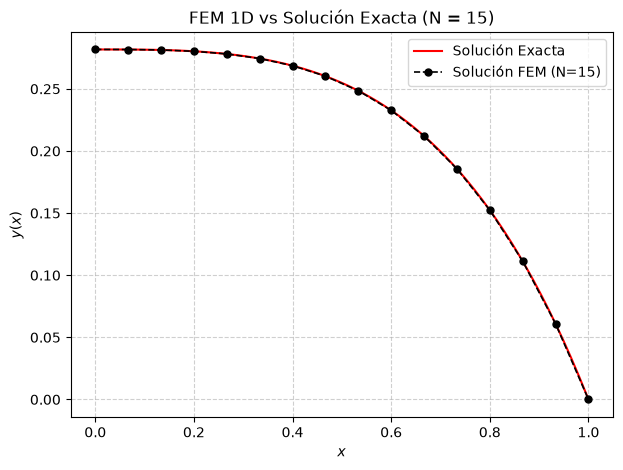

In [2]:
def fem_1d_solver(f_func, a, b, Ua, Ub, N):
    """Resuelve -y''(x) = f(x) en x in [a, b] usando FEM 1D con N elementos.

    Condiciones de frontera: y(a) = Ua, y(b) = Ub.
    """
    # Malla y discretización
    nodes = np.linspace(a, b, N + 1)
    h = (b - a) / N

    # Inicializar Matriz Global A y Vector b
    A = np.zeros((N + 1, N + 1))
    b_vec = np.zeros(N + 1)

    # Ensamble de la Matriz de Rigidez Global (A)
    # Para -y''=f en 1D con elementos lineales, K_elem = 1/h * [[1, -1], [-1, 1]]
    for e in range(N):
        A[e, e] += 1.0 / h
        A[e, e + 1] += -1.0 / h
        A[e + 1, e] += -1.0 / h
        A[e + 1, e + 1] += 1.0 / h

    # Ensamble del Vector de Carga Global (b) integrando f(x)*N_i(x)
    for e in range(N):
        x1, x2 = nodes[e], nodes[e + 1]

        # Funciones de forma locales en el elemento e
        N1 = lambda x: (x2 - x) / h
        N2 = lambda x: (x - x1) / h

        # Integración numérica quad incluyendo la función fuente f(x)
        f1 = integrate.quad(lambda x: f_func(x) * N1(x), x1, x2)[0]
        f2 = integrate.quad(lambda x: f_func(x) * N2(x), x1, x2)[0]

        b_vec[e] += f1
        b_vec[e + 1] += f2

    # Aplicación de Condiciones de Frontera de Dirichlet
    # Para el nodo inicial x=a (índice 0)
    for i in range(1, N + 1):
        b_vec[i] -= A[i, 0] * Ua
    A[0, :] = 0.0
    A[:, 0] = 0.0
    A[0, 0] = 1.0
    b_vec[0] = Ua

    # Para el nodo final x=b (índice N)
    for i in range(N):
        b_vec[i] -= A[i, N] * Ub
    A[N, :] = 0.0
    A[:, N] = 0.0
    A[N, N] = 1.0
    b_vec[N] = Ub

    # Resolver el sistema de ecuaciones lineal
    sol = np.linalg.solve(A, b_vec)

    return nodes, sol


# PROBLEMA ESPECÍFICO 
f = lambda x: x * np.exp(x)  # Fuente
a, b = 0.0, 1.0  # Dominio
Ua, Ub = 3.0 - np.e, 0.0  # Condiciones Dirichlet
exact = lambda x: 1 - np.e - np.exp(x) * (x - 2) - x  # Solución exacta

# Resolvemos con N elementos
N = 15
nodes, sol = fem_1d_solver(f, a, b, Ua, Ub, N)

# --- GRAFICACIÓN DE RESULTADOS ---
x_fine = np.linspace(a, b, 200)

plt.figure(figsize=(7, 5))
plt.plot(x_fine, exact(x_fine), "r-", label="Solución Exacta")
plt.plot(
    nodes,
    sol,
    "ko--",
    label=f"Solución FEM (N={N})",
    markersize=5,
    linewidth=1.2,
)

plt.title(f"FEM 1D vs Solución Exacta (N = {N})")
plt.xlabel("$x$")
plt.ylabel("$y(x)$")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc="best")
plt.show()